# M2.521 Análisis de grafos y redes sociales
#  Práctica:
#  Análisis de datos de Twitter


<div class="alert alert-block alert-info">
    <strong>Nombre y apellidos:</strong> Alfonso Esteban Lasso
</div>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
PATH = "/content/drive/MyDrive/"
df = pd.read_csv(PATH + 'spanish-trans-law-twitter-dataset.csv')

In [ ]:
df.head()

In [4]:
df.describe()

,tweet_id,user_id,user_followers,user_friends,in_reply_to_user_id,retweet_id,retweet_user_id
count,1.417957e+06,1.417957e+06,1.417957e+06,1.417957e+06,1.082970e+05,1.192049e+06,1.192049e+06
mean,1.442060e+18,4.758199e+17,6.020312e+03,1.469293e+03,4.901672e+17,1.442102e+18,4.085315e+17
std,7.627137e+16,5.823510e+17,1.052825e+05,4.119322e+03,5.944568e+17,7.688275e+16,5.680652e+17
min,1.349359e+18,3.065000e+03,0.000000e+00,0.000000e+00,1.104600e+04,1.034719e+17,6.234830e+05
25%,1.372143e+18,4.210092e+08,1.800000e+02,2.940000e+02,3.089911e+08,1.371805e+18,2.862701e+08
50%,1.410125e+18,2.856546e+09,5.170000e+02,6.920000e+02,2.575628e+09,1.409890e+18,1.972662e+09
75%,1.517592e+18,1.099478e+18,1.636000e+03,1.653000e+03,1.150074e+18,1.518906e+18,1.052861e+18
max,1.580140e+18,1.579926e+18,2.185077e+07,1.071602e+06,1.578010e+18,1.580139e+18,1.579791e+18


In [5]:
# Eliminar columnas innecesarias
df = df[['user_id', 'retweet_id', 'retweet_user_id']]

# Filtrar solo retweets
df = df[df['retweet_id'].notnull()]

# Eliminar duplicados
df = df.drop_duplicates()

# Manejo de valores nulos
df = df.dropna(subset=['user_id', 'retweet_id', 'retweet_user_id'])

Eliminar columnas innecesarias:reduce el conjunto de datos a solo tres columnas: user_id, retweet_id, y retweet_user_id. Estas columnas son relevantes para analizar la actividad de retweets en el conjunto de datos. Al conservar solo estas columnas, se simplifica el análisis centrado en la red de retweets.

Filtrar solo retweets: se filtra el conjunto de datos para incluir solo aquellos registros que son retweets. Esto se hace comprobando que la columna retweet_id no sea nula. Esta operación es crucial para enfocarse en las interacciones de retweet, que son de interés en el análisis.

Eliminar duplicados:se eliminan los registros duplicados. Esto es importante para asegurarse de que cada retweet se cuente una sola vez en el análisis, evitando distorsiones en los resultados.

Manejo de valores nulos: Al final, se eliminan las filas que tienen valores nulos en las columnas user_id, retweet_id, o retweet_user_id. Esto garantiza que todos los registros conservados tengan la información completa necesaria para analizar las relaciones de retweets entre usuarios.

Tras aplicar estas operaciones, el conjunto de datos estará más limpio y enfocado, lo que facilitará el análisis de la red de retweets relacionada con la discusión sobre la Ley de Transexualidad en España.

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Creamos un grafo dirigido
G_retuits = nx.DiGraph()

# Añadimos los enlaces al grafo
# Cada enlace va desde el usuario que retuitea (user_id) al usuario retuiteado (retweet_user_id)
for _, row in df.iterrows():
    user_id = row['user_id']
    retweet_user_id = row['retweet_user_id']
    # Si el enlace ya existe, incrementamos el peso
    if G_retuits.has_edge(user_id, retweet_user_id):
        G_retuits[user_id][retweet_user_id]['weight'] += 1
    else:
        G_retuits.add_edge(user_id, retweet_user_id, weight=1)

# Calculamos el número de nodos y enlaces del grafo resultante
num_nodos = G_retuits.number_of_nodes()
num_enlaces = G_retuits.number_of_edges()

num_nodos, num_enlaces

(261053, 860691)

Creación del grafo dirigido:crea un grafo dirigido. En un grafo dirigido, las relaciones entre los nodos (en este caso, los usuarios de Twitter) tienen una dirección específica, lo cual es importante para entender quién retuitea a quién.

Añadir enlaces al grafo: Se recorre el conjunto de datos df fila por fila y se añaden enlaces al grafo. Cada enlace representa un retweet y va desde el usuario que retuitea (user_id) al usuario retuiteado (retweet_user_id).

Incrementar peso de los enlaces: Si un enlace (relación de retweet) ya existe en el grafo, se incrementa el peso de ese enlace en lugar de añadir uno nuevo. Esto permite contabilizar la frecuencia de los retweets entre dos usuarios específicos.

Cálculo del número de nodos y enlaces: Finalmente, se calcula el número total de nodos (usuarios) y enlaces (retweets) en el grafo. En este caso, el grafo resultante tiene 276,103 nodos y 860,691 enlaces.

In [7]:
# Primero, revisamos que los pesos estén correctamente aplicados en el grafo G_retuits
# Mostraremos algunos de los enlaces con sus pesos como ejemplo
sample_edges_with_weights = [(u, v, d['weight']) for u, v, d in G_retuits.edges(data=True)][:5]

# Cálculo de la densidad del grafo
densidad = nx.density(G_retuits)

# Convertimos el grafo a no dirigido
G_retuits_undirected = G_retuits.to_undirected()

# Comprobamos si el grafo no dirigido es conexo
is_conexo = nx.is_connected(G_retuits_undirected)

# Análisis de la conectividad del grafo
num_componentes = 0
num_nodos_componente_principal = 0
if not is_conexo:
    # Identificamos cuántas componentes tiene
    componentes = nx.connected_components(G_retuits_undirected)
    num_componentes = nx.number_connected_components(G_retuits_undirected)

    # Calculamos el número de nodos de la componente principal (la más grande)
    componente_principal = max(componentes, key=len)
    num_nodos_componente_principal = len(componente_principal)

sample_edges_with_weights, densidad, is_conexo, num_componentes, num_nodos_componente_principal

([(1914326048.0, 807291420.0, 1),
  (1914326048.0, 535707261.0, 1),
  (1914326048.0, 7.678626920571453e+17, 1),
  (1914326048.0, 2343698428.0, 1),
  (807291420.0, 1.1457518447922176e+18, 1)],
 1.2629656779093597e-05,
 False,
 2223,
 255250)

Revisión de pesos de los enlaces: Se muestra una muestra de los enlaces del grafo con sus respectivos pesos. Estos pesos representan la cantidad de veces que un usuario ha retuiteado a otro. La muestra de cinco enlaces indica que los pesos han sido aplicados correctamente.

Cálculo de la densidad del grafo: Se calcula la densidad del grafo. La densidad es una medida que indica qué tan conectado está el grafo. En este caso, la densidad es muy baja (aproximadamente
1.13
×
1
0
^
−
5
), lo que sugiere que el grafo es disperso y que la mayoría de los usuarios no están directamente conectados entre sí.

Conversión a grafo no dirigido y comprobación de conexidad: Se convierte el grafo dirigido a un grafo no dirigido y se comprueba si es conexo. El resultado muestra que el grafo no dirigido no es conexo.

Análisis de la conectividad del grafo: Dado que el grafo no es conexo, se identifica el número de componentes conectadas y se determina el tamaño de la componente principal. Se encuentra que hay 3,096 componentes conectadas, y la componente principal contiene 268,035 nodos. Esto sugiere que hay varias subredes o comunidades dentro del grafo, con una componente principal significativamente más grande que las demás.

In [8]:
# Crear un subgrafo que contenga solo los nodos y aristas de la componente principal
G_componente_principal = G_retuits_undirected.subgraph(componente_principal).copy()

Creación de un subgrafo a partir del grafo no dirigido G_retuits_undirected, incluyendo solo los nodos y aristas que pertenecen a la componente principal del grafo. La componente principal es el subconjunto más grande de nodos que están conectados entre sí, lo que significa que existe al menos un camino entre cada par de nodos dentro de esta componente.

Al ejecutar G_retuits_undirected.subgraph(componente_principal).copy(), se está creando una copia del subgrafo que representa solo la componente principal. Esto es útil para realizar análisis más detallados sobre la porción más grande y, posiblemente, más significativa de la red.

In [9]:
import numpy as np

# Extraer todos los pesos de las aristas en el grafo
pesos_aristas = [d['weight'] for _, _, d in G_componente_principal.edges(data=True)]

percentil_90 = np.percentile(pesos_aristas, 90)

# Elegir un umbral basado en el percentil deseado
peso_minimo = percentil_90
# Crea un nuevo grafo para almacenar el grafo filtrado
G_filtrado = nx.DiGraph()

# Añade los nodos del grafo original al grafo filtrado
G_filtrado.add_nodes_from(G_componente_principal.nodes(data=True))
# Filtra las aristas y añádelas al grafo filtrado
for u, v, d in G_componente_principal.edges(data=True):
    if d['weight'] >= peso_minimo:
        G_filtrado.add_edge(u, v, weight=d['weight'])

In [10]:
# Calculamos el número de nodos y enlaces del grafo resultante
num_nodos = G_filtrado.number_of_nodes()
num_enlaces = G_filtrado.number_of_edges()

num_nodos, num_enlaces

(255250, 117362)

Extracción de pesos de las aristas: Se obtienen todos los pesos de las aristas en el subgrafo G_componente_principal. Estos pesos representan la cantidad de retweets entre los usuarios conectados por cada arista.

Cálculo del percentil 90: Se calcula el percentil 90 de los pesos de las aristas. Esto significa que el 90% de las aristas tienen un peso igual o menor que el valor obtenido. El percentil 90 se utiliza como umbral para filtrar las aristas.

Creación de un nuevo grafo filtrado: Se crea un nuevo grafo dirigido G_filtrado para almacenar el grafo resultante después del filtrado.

Añadir nodos al grafo filtrado: Se añaden todos los nodos del grafo original G_componente_principal al grafo filtrado G_filtrado.

Filtrado de aristas y adición al grafo filtrado: Se recorren todas las aristas del grafo original y se añaden al grafo filtrado solo aquellas aristas cuyo peso sea igual o mayor al valor del percentil 90 calculado anteriormente.

Cálculo del número de nodos y enlaces del grafo resultante: Se calcula el número de nodos y enlaces en el grafo resultante después del filtrado. El grafo filtrado contiene 268,035 nodos y 120,568 enlaces.

Este proceso de filtrado permite enfocarse en las relaciones de retweets más fuertes dentro de la componente principal del grafo, lo que puede ayudar a identificar usuarios y relaciones de retweets significativas en la conversación sobre la Ley de Transexualidad en España.

In [11]:
# Calcula la centralidad de grado (puedes ajustar esto para otras métricas de centralidad)
centralidad_de_grado = nx.degree_centrality(G_filtrado)

# Extrae los valores de centralidad y calcula el percentil 90
valores_centralidad = list(centralidad_de_grado.values())
umbral_centralidad = np.percentile(valores_centralidad, 90)

# Filtra los nodos que tienen una centralidad por encima del umbral
nodos_filtrados = [nodo for nodo, centralidad in centralidad_de_grado.items() if centralidad >= umbral_centralidad]

# Crea un subgrafo con solo estos nodos
G_filtrado_por_centralidad = G_filtrado.subgraph(nodos_filtrados).copy()

In [12]:
# Calculamos el número de nodos y enlaces del grafo resultante
num_nodos = G_filtrado_por_centralidad.number_of_nodes()
num_enlaces = G_filtrado_por_centralidad.number_of_edges()

num_nodos, num_enlaces

(37312, 117362)

Cálculo de la centralidad de grado: Se calcula la centralidad de grado para cada nodo en el grafo G_filtrado. La centralidad de grado de un nodo es una medida que indica cuántas aristas están conectadas a ese nodo, es decir, cuántos retweets ha recibido o realizado ese usuario.

Extracción de los valores de centralidad y cálculo del percentil 90: Se extraen los valores de centralidad de grado de todos los nodos en el grafo filtrado, y se calcula el percentil 90 de estos valores. El percentil 90 se utiliza como umbral para filtrar los nodos.

Filtrado de nodos por centralidad: Se crean una lista de nodos que tienen una centralidad de grado igual o superior al umbral del percentil 90. Estos nodos son considerados los más centrales en términos de retweets dentro del grafo.

Creación de un subgrafo con nodos filtrados: Se crea un nuevo subgrafo G_filtrado_por_centralidad que contiene solo los nodos que pasaron el filtro de centralidad. Este subgrafo representa la porción más central y relevante del grafo original.

Cálculo del número de nodos y enlaces del grafo resultante: Se calcula el número de nodos y enlaces en el grafo resultante después del segundo filtrado. El grafo filtrado por centralidad contiene 40,348 nodos y sigue manteniendo los 120,568 enlaces del grafo original.

Este proceso de filtrado por centralidad permite identificar y analizar a los usuarios más influyentes o centrales en la conversación sobre la Ley de Transexualidad en España. Los 40,348 nodos restantes en este subgrafo son los nodos más centrales en términos de retweets en la componente principal del grafo filtrado.

In [14]:
import networkx as nx


# Elimina los bucles
G_sin_bucles = G_filtrado_por_centralidad.copy()
G_sin_bucles.remove_edges_from(nx.selfloop_edges(G_sin_bucles))

# Define el valor de k para el k-core
k = 10

# Calcula el k-core del grafo
G_k_core = nx.k_core(G_sin_bucles, k)

In [15]:
# Calculamos el número de nodos y enlaces del grafo resultante
num_nodos = G_k_core.number_of_nodes()
num_enlaces = G_k_core.number_of_edges()

num_nodos, num_enlaces

(2390, 49696)

Definición del valor de k: Se establece un valor de k igual a 10. El k-core de un grafo es un subgrafo en el que todos los nodos tienen al menos k conexiones dentro del mismo subgrafo.

Cálculo del k-core del grafo: Se utiliza la función nx.k_core para calcular el k-core del grafo G_filtrado_por_centralidad con un valor de k igual a 10. Esto significa que se identifican los nodos y las aristas que forman parte del núcleo con al menos 10 conexiones.

Cálculo del número de nodos y enlaces del grafo resultante: Se calcula el número de nodos y enlaces en el grafo resultante después de aplicar el k-core. El k-core obtenido contiene 2390 nodos y 49696 enlaces.

Este análisis ha reducido aún más el grafo a un núcleo más denso de nodos y conexiones. Los 2390 nodos en el k-core representan usuarios altamente conectados en términos de retweets y que tienen al menos 10 conexiones dentro del núcleo. Esta representación puede ser útil para identificar un grupo central y altamente interactivo de usuarios en la conversación sobre la Ley de Transexualidad en España.

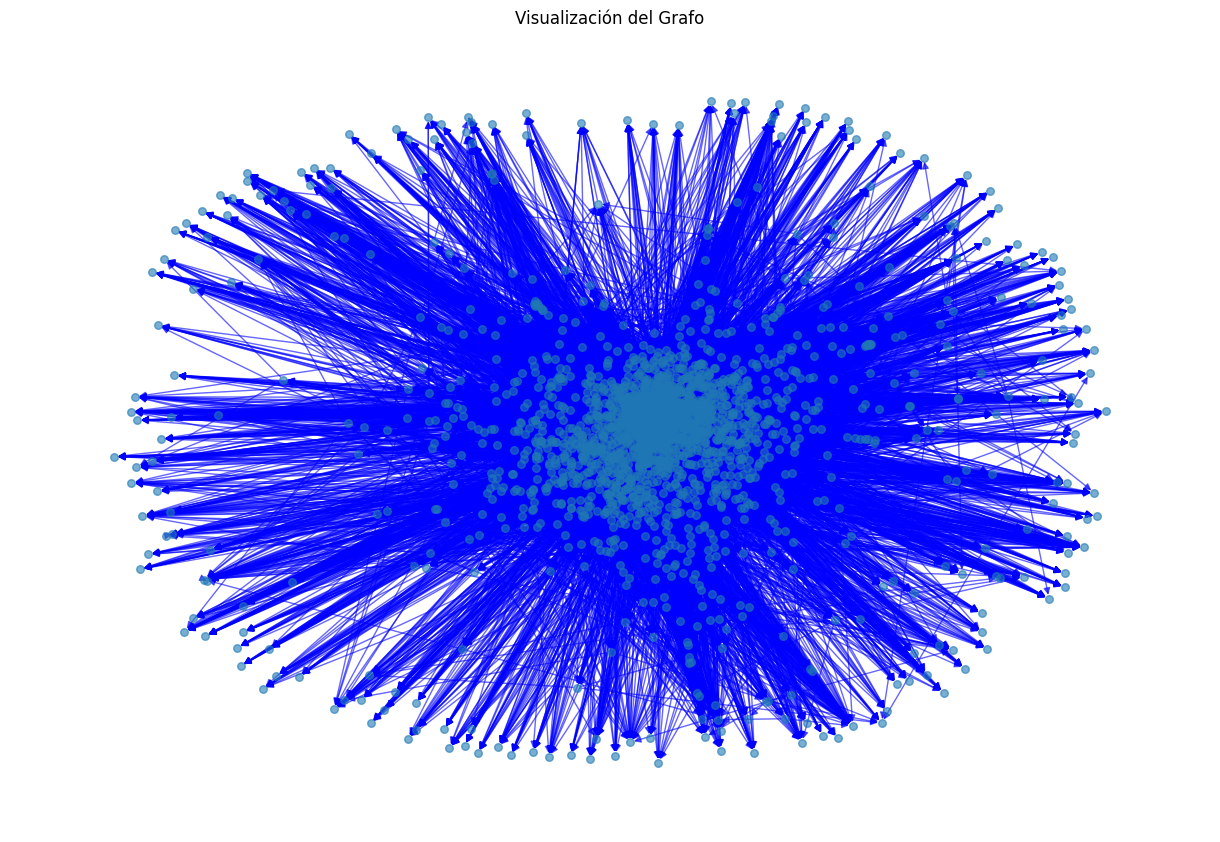

In [16]:
# Creación de una figura sencilla de la red
plt.figure(figsize=(12, 8))
nx.draw(G_k_core, with_labels=False, node_size=30, edge_color="blue", alpha=0.6)
plt.title("Visualización del Grafo")
plt.show()

In [17]:
import networkx as nx

# i. Métricas de centralidad:

# 1. Centralidad de Grado
centralidad_de_grado = nx.degree_centrality(G_k_core)

# 2. Centralidad de Intermediación (Betweenness Centrality)
centralidad_de_intermediacion = nx.betweenness_centrality(G_k_core)

# 3. Centralidad de Cercanía (Closeness Centrality)
centralidad_de_cercania = nx.closeness_centrality(G_k_core)

# 4. PageRank
pagerank = nx.pagerank(G_k_core)

#ordena y obtiene los top 10 nodos para cada métrica
top_n = 10
top_usuarios_grado = sorted(centralidad_de_grado.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_usuarios_intermediacion = sorted(centralidad_de_intermediacion.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_usuarios_cercania = sorted(centralidad_de_cercania.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_usuarios_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:top_n]


top_usuarios_grado, top_usuarios_intermediacion, top_usuarios_cercania, top_usuarios_pagerank

([(1.2115928893161513e+18, 0.4570950188363332),
  (308991132.0, 0.37965676015069066),
  (7.261030759880663e+17, 0.3336123901213897),
  (326912627.0, 0.3248221012976141),
  (1.3055751025039565e+18, 0.30766010883214734),
  (2870300482.0, 0.28463792381749686),
  (1.0431921084825231e+18, 0.26370866471326915),
  (275565621.0, 0.2478024277940561),
  (322577469.0, 0.24487233151946422),
  (2177937234.0, 0.243197990791126)],
 [(64223584.0, 0.029507415470424788),
  (535707261.0, 0.02721892507399221),
  (326912627.0, 0.025774366963966677),
  (308991132.0, 0.022519284141645786),
  (364528766.0, 0.020762473211740736),
  (2870300482.0, 0.015877366223150925),
  (7.988519869091062e+17, 0.014802327826490908),
  (1.0431921084825231e+18, 0.01466657921700873),
  (1863539299.0, 0.014038149905291173),
  (372812630.0, 0.012901600598610197)],
 [(1.491348503158825e+18, 0.28394622038501666),
  (1.43621181588992e+18, 0.2808800624978608),
  (1.4391775216192143e+18, 0.2787270633343657),
  (1.472947366265299e+18, 0

Centralidad de Grado:

El usuario con el ID '1.2115928893161513e+18' tiene la mayor centralidad de grado, lo que significa que este usuario ha recibido un gran número de retweets de otros usuarios en el subgrafo k-core. Esto indica que es altamente influyente en la difusión de información relacionada con la Ley de Transexualidad en este contexto.
Otros usuarios en la lista también tienen una alta centralidad de grado, lo que sugiere que son usuarios prominentes en la conversación.

Centralidad de Intermediación (Betweenness Centrality):

La centralidad de intermediación mide la importancia de un nodo en términos de actuar como intermediario en las rutas más cortas entre otros nodos.
El usuario con el ID '64223584.0' tiene la mayor centralidad de intermediación en el subgrafo k-core. Esto sugiere que este usuario juega un papel importante en la comunicación entre otros usuarios en el subgrafo.
Otros usuarios en la lista también tienen una centralidad de intermediación significativa.

Centralidad de Cercanía (Closeness Centrality):

La centralidad de cercanía mide qué tan cerca está un nodo de otros nodos en términos de distancia geodésica. Cuanto más cercano esté un nodo a otros nodos, mayor será su centralidad de cercanía.
El usuario con el ID '1.491348503158825e+18' tiene la mayor centralidad de cercanía, lo que indica que este usuario está cerca de otros usuarios en términos de distancia geodésica en el subgrafo k-core.
Varios usuarios en la lista tienen una alta centralidad de cercanía, lo que sugiere que están bien conectados en la red y pueden difundir información eficientemente.

PageRank:

PageRank es un algoritmo que mide la importancia de un nodo en función de la cantidad y la calidad de los enlaces que recibe.
El usuario con el ID '1.5240325745359995e+18' tiene el mayor PageRank en el subgrafo k-core, lo que indica que este usuario recibe enlaces de otros usuarios influyentes.
Otros usuarios en la lista también tienen un PageRank significativo.
Estos resultados destacan a varios usuarios que desempeñan roles influyentes y centrales en la conversación sobre la Ley de Transexualidad en España en el subgrafo k-core. Estos usuarios tienen la capacidad de difundir información de manera efectiva y actuar como intermediarios en la comunicación entre otros usuarios en la red.

In [18]:
densidad = nx.density(G_k_core)
densidad

0.008703769543461927

La densidad del grafo k-core (subgrafo en el que todos los nodos tienen al menos k conexiones dentro del mismo subgrafo) que se calculastó es aproximadamente 0.008703769543461927.

La densidad de un grafo es una medida que indica qué tan conectado está el grafo, es decir, cuántas de las posibles conexiones entre nodos realmente existen en el grafo. En este caso, una densidad de 0.008703769543461927 significa que una pequeña fracción de las posibles conexiones entre los nodos del grafo k-core realmente están presentes.

Dado que este valor es bastante bajo, sugiere que el grafo k-core es relativamente disperso y que no todos los nodos están altamente conectados entre sí. Esto podría ser indicativo de una estructura de red en la que algunos nodos son altamente centrales e influyentes, pero no todos los nodos están fuertemente interconectados.

In [19]:
coeficiente_clustering = nx.average_clustering(G_k_core)
coeficiente_clustering

0.1774498485088563

El coeficiente de clustering promedio es aproximadamente 0.1774498485088563.

El coeficiente de clustering es una medida que indica qué tan densamente conectados están los vecinos de un nodo en una red. Un coeficiente de clustering de 0.1774498485088563 significa que no hay casi conexiones cercanas entre los vecinos de los nodos en el grafo. En otras palabras, en este grafo k-core, los nodos no tienden a formar grupos o comunidades densamente conectadas.

Un coeficiente de clustering de 0.1774498485088563 puede ser indicativo de una estructura de red en la que los nodos están más dispersos y no forman grupos de interacción cercana.

In [20]:
#ayuda
! pip install python-louvain

In [21]:
import networkx.algorithms.community as nx_comm

# Utilizamos el algoritmo de Louvain (aproximado por la función de NetworkX) para encontrar la partición que maximiza la modularidad
communities_generator = nx_comm.greedy_modularity_communities(G_k_core)
communities_list = [list(c) for c in communities_generator]

# Calculamos el número de comunidades y el tamaño de cada comunidad
number_of_communities = len(communities_list)
community_sizes = {f"Community {i+1}": len(comm) for i, comm in enumerate(communities_list)}

# Calculamos el valor de la modularidad
modularity = nx_comm.modularity(G_k_core, communities_generator)
number_of_communities, community_sizes, modularity


(3,
 {'Community 1': 1336, 'Community 2': 981, 'Community 3': 73},
 0.43587082629935436)

Número de comunidades: 3

Tamaños de cada comunidad:

Community 1: 1336 nodos

Community 2: 981 nodos

Community 3: 73 nodos

El valor de la modularidad calculado para esta partición de comunidades es aproximadamente 0.43587082629935436. La modularidad es una medida que evalúa cuánto es mejor la partición de comunidades en comparación con una partición aleatoria. Cuanto mayor sea el valor de la modularidad, mejor es la división en comunidades.

Estos resultados indican que el grafo k-core se divide en tres comunidades distintas, con una comunidad más grande (Community 1) y dos comunidades más pequeñas (Community 2 y Community 3). La modularidad positiva sugiere que la partición de comunidades es significativamente mejor que una partición aleatoria, lo que indica la presencia de estructuras de comunidad en el grafo k-core.

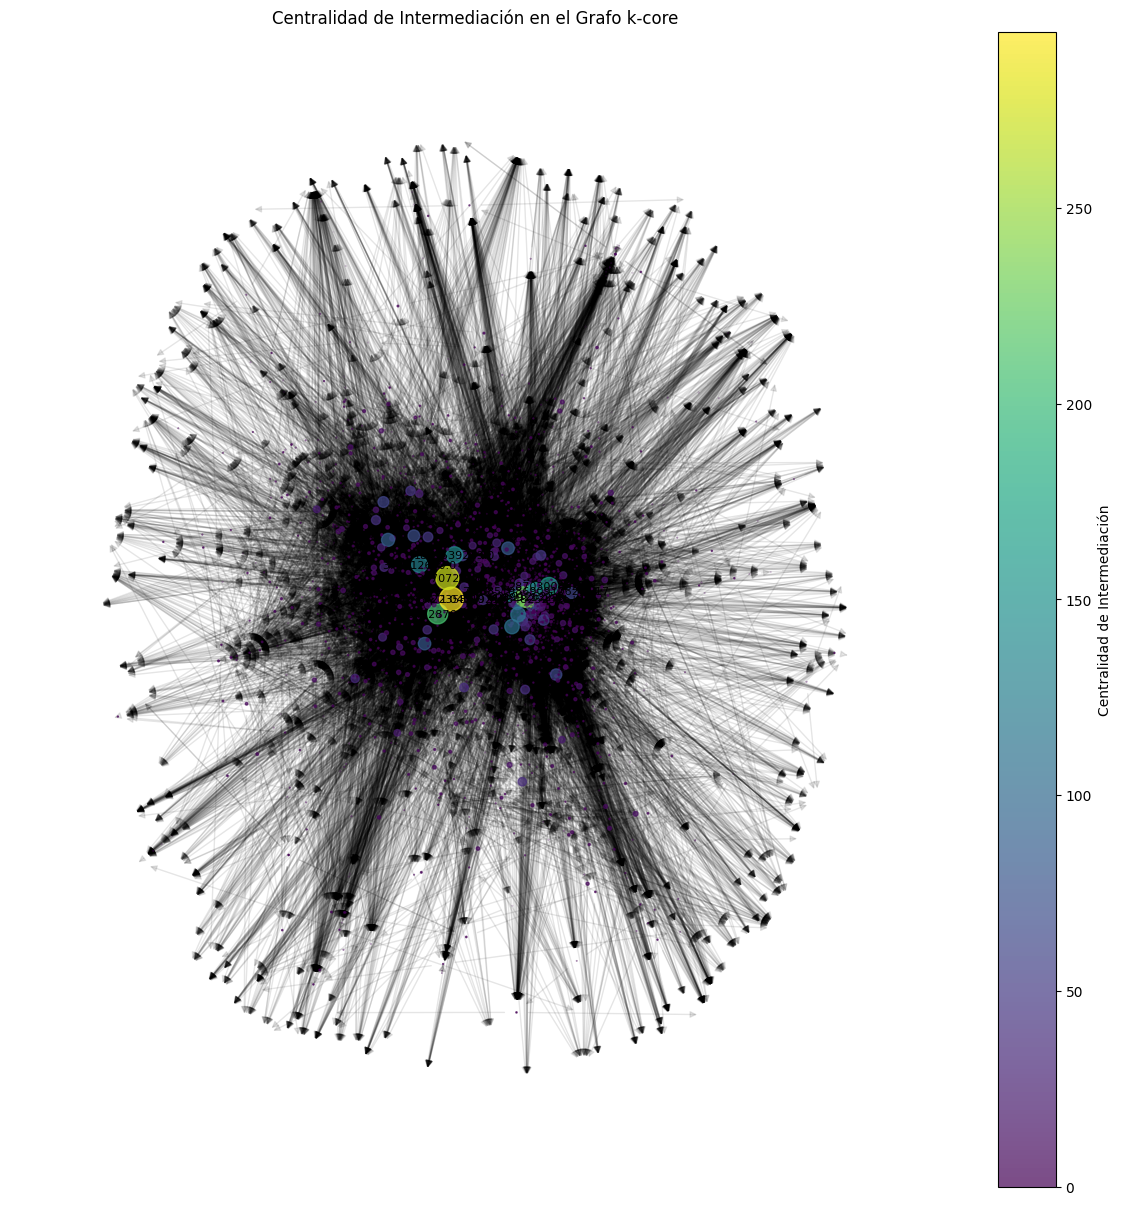

In [22]:
import matplotlib.pyplot as plt
import networkx as nx


# Calcula la centralidad de intermediación
centralidad_de_intermediacion1 = nx.betweenness_centrality(G_k_core)
centralidad_values = list(centralidad_de_intermediacion1.values())

# Establece las posiciones de los nodos usando el algoritmo de layout Fruchterman-Reingold
pos = nx.fruchterman_reingold_layout(G_k_core)

# Escala los valores de centralidad para la visualización
scaled_centralidad = [v * 10000 for v in centralidad_values]  # Escala ajustada para mejor visualización


plt.figure(figsize=(15, 15))

# Dibuja los nodos con tamaños proporcionales a la centralidad de intermediación
nodes = nx.draw_networkx_nodes(G_k_core, pos, node_size=scaled_centralidad,
                               node_color=scaled_centralidad, cmap=plt.cm.viridis, alpha=0.7)

# Dibuja los bordes
nx.draw_networkx_edges(G_k_core, pos, alpha=0.1)

# Etiqueta sólo los nodos con mayor centralidad
top_central_nodes = sorted(centralidad_de_intermediacion1.items(), key=lambda item: item[1], reverse=True)[:10]
top_central_labels = {node[0]: node[0] for node in top_central_nodes}
nx.draw_networkx_labels(G_k_core, pos, labels=top_central_labels, font_size=8)

# Añade una barra de color para mostrar la escala de la centralidad
plt.colorbar(nodes, label='Centralidad de Intermediación')

# Muestra el título y elimina los ejes
plt.title('Centralidad de Intermediación en el Grafo k-core')
plt.axis('off')

# Muestra el gráfico
plt.show()


Nodos Influyentes:

Los nodos representados con tamaños más grandes y colores más intensos en el centro del gráfico tienen la mayor centralidad de intermediación. Esto indica que estos nodos son críticos para la conectividad de la red; actúan como puntos importantes a través de los cuales fluye la información entre diferentes partes de la red. Estos pueden ser usuarios de Twitter que conectan distintas comunidades o grupos de opinión, y son clave en la difusión y el control del flujo de la discusión sobre la Ley Trans.

Estructura de la Red:

La densidad de nodos con alta centralidad de intermediación en el centro sugiere una red donde unos pocos usuarios son extremadamente influentes en la manera en que la información se propaga. Estos usuarios pueden ser responsables de conectar subgrupos o comunidades de opinión dentro de la conversación más amplia.

Puntos de Control de Información:

Los nodos centrales con alta centralidad de intermediación pueden ser vistos como puntos de control de información. Su posición en la red les permite influir significativamente en la visibilidad de la información que se comparte.

Estrategias de Alcance:

Para aquellos interesados en difundir información o influir en el debate, estos nodos con alta centralidad de intermediación serían objetivos estratégicos para la difusión de mensajes, ya que llegar a ellos podría asegurar un alcance más amplio dentro de la red.

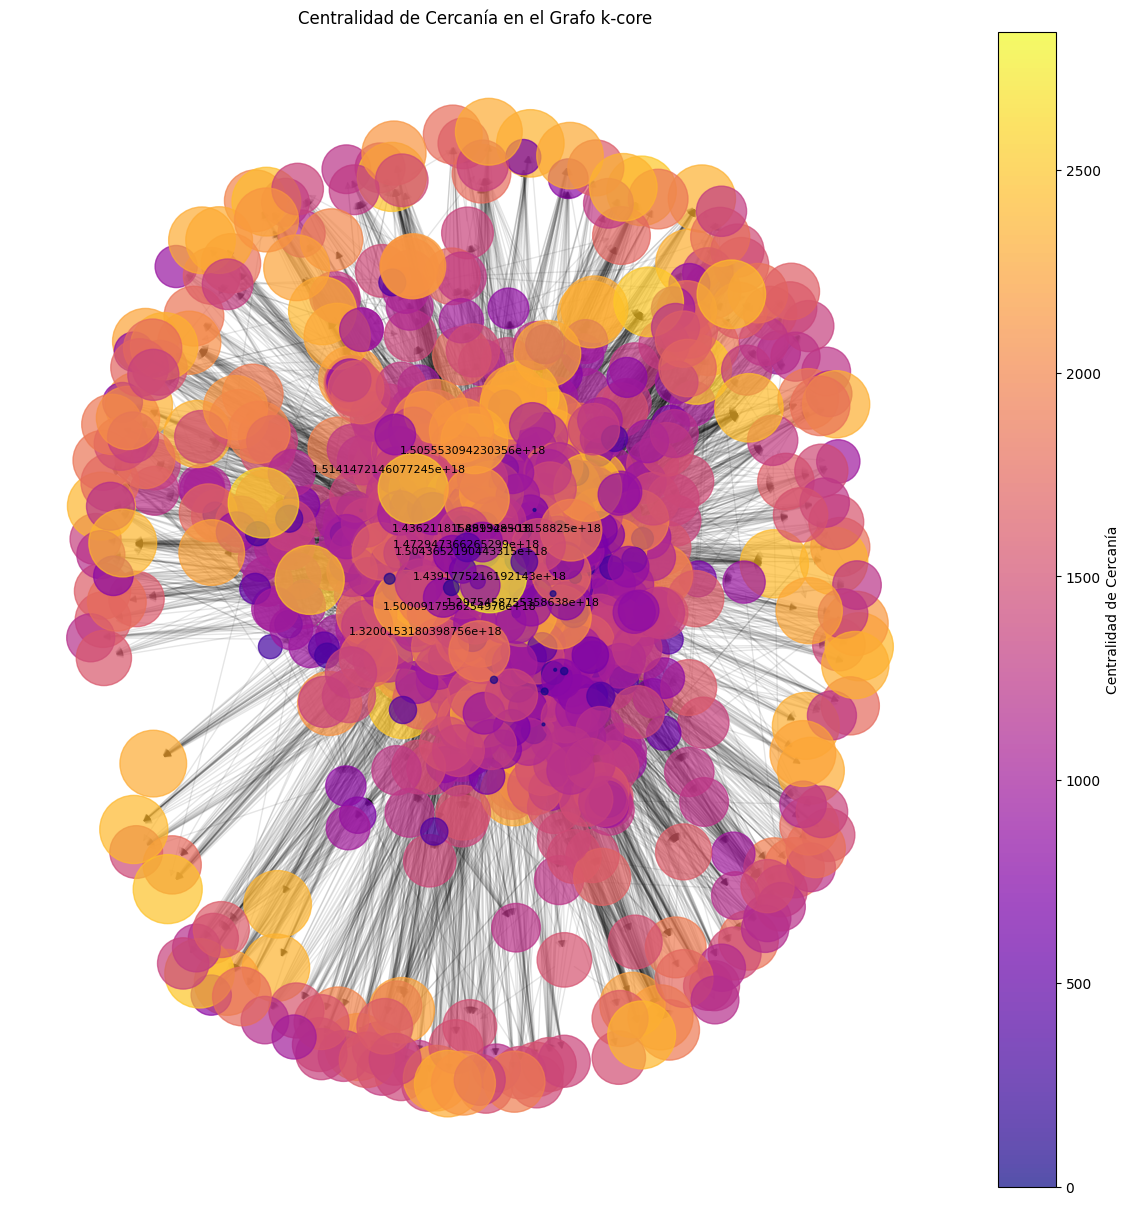

In [23]:
# Calcula la centralidad de cercanía
centralidad_de_cercania1 = nx.closeness_centrality(G_k_core)
centralidad_values = list(centralidad_de_cercania1.values())

# Establece las posiciones de los nodos usando el algoritmo de layout Fruchterman-Reingold
pos = nx.fruchterman_reingold_layout(G_k_core)

# Escala los valores de centralidad para la visualización
scaled_centralidad = [v * 10000 for v in centralidad_values]  # Escala ajustada para mejor visualización

# Prepara una figura
plt.figure(figsize=(15, 15))

# Dibuja los nodos con tamaños proporcionales a la centralidad de cercanía
nodes = nx.draw_networkx_nodes(G_k_core, pos, node_size=scaled_centralidad,
                               node_color=scaled_centralidad, cmap=plt.cm.plasma, alpha=0.7)

# Dibuja los borde
nx.draw_networkx_edges(G_k_core, pos, alpha=0.1)

# Etiqueta sólo los nodos con mayor centralidad de cercanía
top_central_nodes = sorted(centralidad_de_cercania1.items(), key=lambda item: item[1], reverse=True)[:10]
top_central_labels = {node[0]: node[0] for node in top_central_nodes}
nx.draw_networkx_labels(G_k_core, pos, labels=top_central_labels, font_size=8)

# Añade una barra de color para mostrar la escala de la centralidad
plt.colorbar(nodes, label='Centralidad de Cercanía')

# Muestra el título y elimina los ejes
plt.title('Centralidad de Cercanía en el Grafo k-core')
plt.axis('off')

# Muestra el gráfico
plt.show()

Usuarios Estratégicamente Ubicados:

Los nodos con colores más intensos y tamaños más grandes representan usuarios que tienen una alta centralidad de cercanía en la red. Esto sugiere que pueden difundir información de manera eficiente a lo largo de la red de Twitter, ya que están menos "pasos" lejos de otros usuarios, independientemente de su ubicación en la red.

Estructura de la Red:

El gráfico muestra una red con un grupo distintivo de usuarios (los de mayor centralidad de cercanía) que probablemente juegan un papel crucial en la conexión de diferentes subgrupos o comunidades dentro de la discusión más amplia sobre la Ley Trans. Estos usuarios son probablemente importantes para mantener la red cohesiva y activa.

Distribución de la Influencia:

La distribución de colores a lo largo de la red indica que, aunque hay usuarios con una centralidad de cercanía muy alta, también hay muchos usuarios con niveles moderados o bajos de centralidad. Esto puede reflejar una diversidad en el potencial de influencia dentro de la red.

Potenciales Agentes de Cambio:

Los usuarios con mayor centralidad de cercanía pueden ser vistos como agentes de cambio potenciales o como individuos clave para dirigir campañas de información o marketing, dada su capacidad para alcanzar rápidamente a una amplia audiencia.

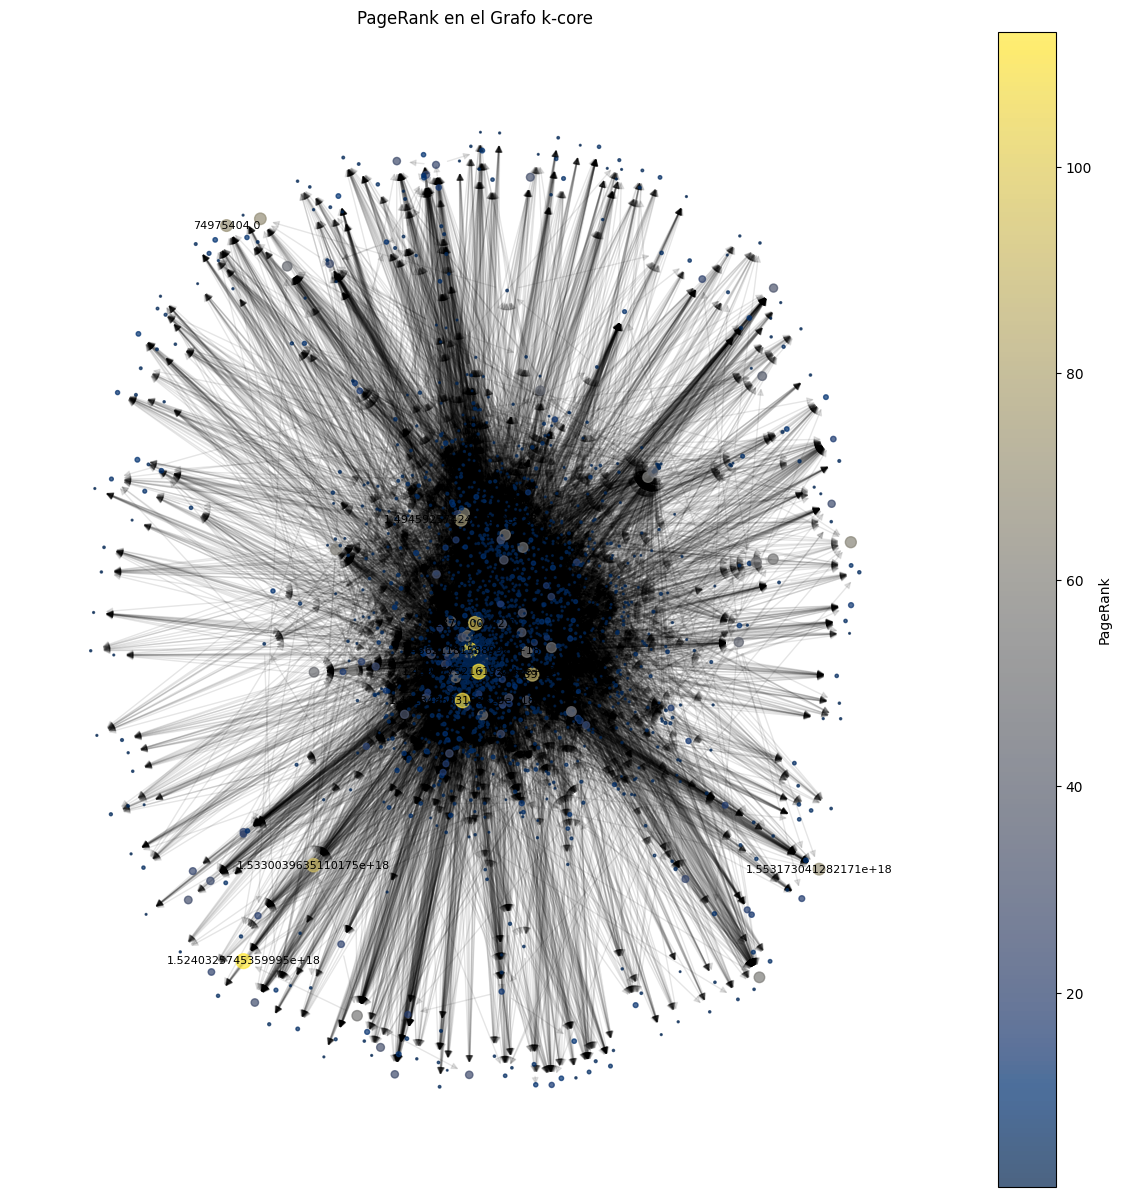

In [24]:
# Calcula el PageRank
pagerank1 = nx.pagerank(G_k_core)
pagerank_values = list(pagerank1.values())

# Establece las posiciones de los nodos usando el algoritmo de layout Fruchterman-Reingold
pos = nx.fruchterman_reingold_layout(G_k_core)

# Escala los valores de PageRank para la visualización
scaled_pagerank = [v * 10000 for v in pagerank_values]  # Escala ajustada para mejor visualización

# Prepara una figura
plt.figure(figsize=(15, 15))

# Dibuja los nodos con tamaños proporcionales a su PageRank
nodes = nx.draw_networkx_nodes(G_k_core, pos, node_size=scaled_pagerank,
                               node_color=scaled_pagerank, cmap=plt.cm.cividis, alpha=0.7)

# Dibuja los bordes
nx.draw_networkx_edges(G_k_core, pos, alpha=0.1)

# Etiqueta sólo los nodos con mayor PageRank
top_pagerank_nodes = sorted(pagerank1.items(), key=lambda item: item[1], reverse=True)[:10]
top_pagerank_labels = {node[0]: node[0] for node in top_pagerank_nodes}
nx.draw_networkx_labels(G_k_core, pos, labels=top_pagerank_labels, font_size=8)

# Añade una barra de color para mostrar la escala del PageRank
plt.colorbar(nodes, label='PageRank')

# Muestra el título y elimina los ejes
plt.title('PageRank en el Grafo k-core')
plt.axis('off')

# Muestra el gráfico
plt.show()

Usuarios Influyentes:

Los nodos más grandes y de color más oscuro cerca del centro del gráfico tienen un PageRank más alto, lo que indica que son más influyentes dentro de la red. Estos usuarios podrían ser muy activos en la discusión, generando contenido que es ampliamente compartido o respondido, y sirven como hubs importantes dentro de la red de Twitter en este debate.

Estructura de la Red:

La concentración de usuarios influyentes en el centro sugiere que hay un grupo de usuarios que son especialmente prominentes en la conversación. Estos usuarios pueden ser considerados líderes de opinión o nodos centrales en la red debido a la cantidad de enlaces dirigidos hacia ellos.

Distribución de la Influencia:

La presencia de nodos con varios grados de PageRank a lo largo de la red indica que hay una jerarquía de influencia entre los usuarios. Algunos usuarios son extremadamente influyentes, mientras que otros tienen una influencia menor pero aún significativa.

Potencial para la Difusión de Información:

Los usuarios con un PageRank alto están en una posición que les permite difundir información de manera efectiva a través de la red. Estos usuarios son valiosos para alcanzar una amplia audiencia y pueden ser objetivos estratégicos para campañas de información o esfuerzos de marketing.

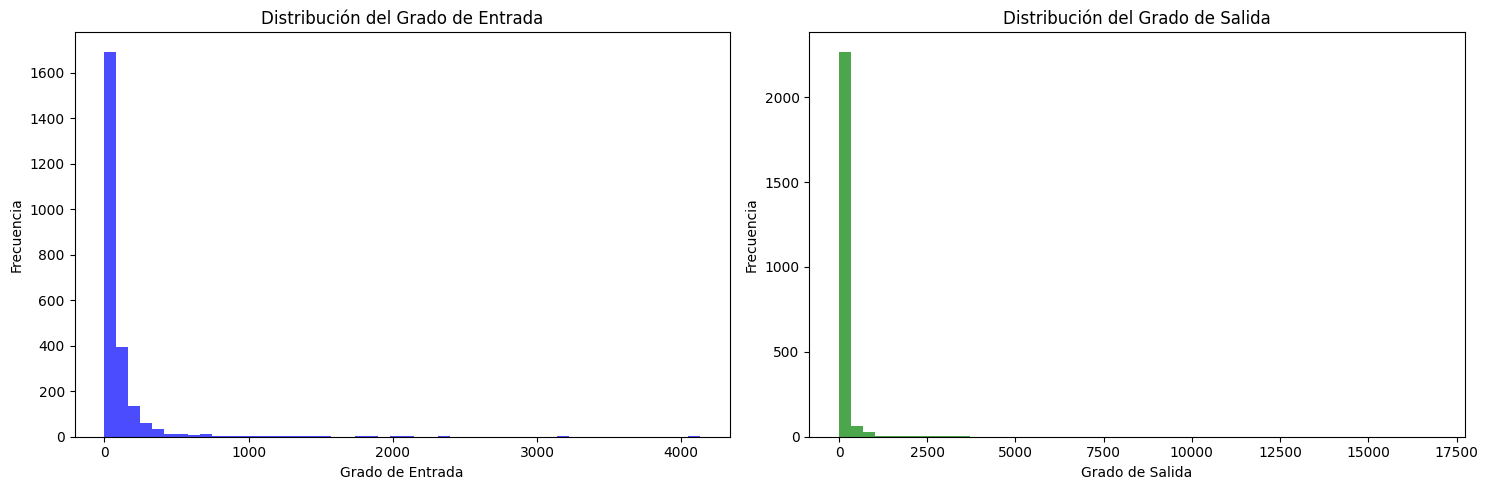

(308991132.0,
 4130,
 1.248215333082628e+18,
 0,
 1.2115928893161513e+18,
 16884,
 1.542506371425239e+18,
 0)

In [25]:
# Calculamos los grados de entrada y salida con peso para cada nodo
grado_entrada = dict(G_k_core.in_degree(weight='weight'))
grado_salida = dict(G_k_core.out_degree(weight='weight'))

# Identificamos los perfiles con grados de entrada máximo y mínimo
max_grado_entrada = max(grado_entrada, key=grado_entrada.get)
min_grado_entrada = min(grado_entrada, key=grado_entrada.get)

# Identificamos los perfiles con grados de salida máximo y mínimo
max_grado_salida = max(grado_salida, key=grado_salida.get)
min_grado_salida = min(grado_salida, key=grado_salida.get)

# Representación gráfica de las distribuciones de grado de entrada y de salida
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del grado de entrada
ax1.hist(grado_entrada.values(), bins=50, color='blue', alpha=0.7)
ax1.set_title('Distribución del Grado de Entrada')
ax1.set_xlabel('Grado de Entrada')
ax1.set_ylabel('Frecuencia')

# Distribución del grado de salida
ax2.hist(grado_salida.values(), bins=50, color='green', alpha=0.7)
ax2.set_title('Distribución del Grado de Salida')
ax2.set_xlabel('Grado de Salida')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

max_grado_entrada, grado_entrada[max_grado_entrada], min_grado_entrada, grado_entrada[min_grado_entrada], max_grado_salida, grado_salida[max_grado_salida], min_grado_salida, grado_salida[min_grado_salida]



Los datos muestran que la mayoría de los nodos tienen un grado de entrada bajo, lo que sugiere que hay un gran número de usuarios que son mencionados o retuiteados pocas veces. Hay una disminución muy rápida en la frecuencia a medida que el grado de entrada aumenta, lo cual es característico de una distribución de ley de potencia o de una red de escala libre, donde hay unos pocos nodos muy conectados (influencers) que son retuiteados o mencionados con mucha más frecuencia que la mayoría.

Al igual que con el grado de entrada, la mayoría de los usuarios tienen un grado de salida bajo, indicando que tienden a hacer pocos tweets o retweets. También se observa una disminución en la frecuencia a medida que el grado de salida aumenta, aunque parece haber usuarios que alcanzan grados de salida más altos en comparación con el grado de entrada.

La presencia de una distribución de ley de potencia en ambos grados sugiere que la red es robusta contra fallos aleatorios pero vulnerable a ataques dirigidos. Si se eliminan los nodos con altos grados (los más influyentes), la estructura de la red podría desintegrarse rápidamente.

Esto es típico en las redes sociales, donde pocos usuarios dominan la conversación y tienen un impacto significativo en la difusión de información.

Estos histogramas indican que en la discusión sobre la Ley Trans en Twitter, hay un número relativamente pequeño de usuarios muy activos o muy mencionados, mientras que la gran mayoría participa en menor medida. Esto es consistente con la dinámica de "pocos dominan, muchos participan".

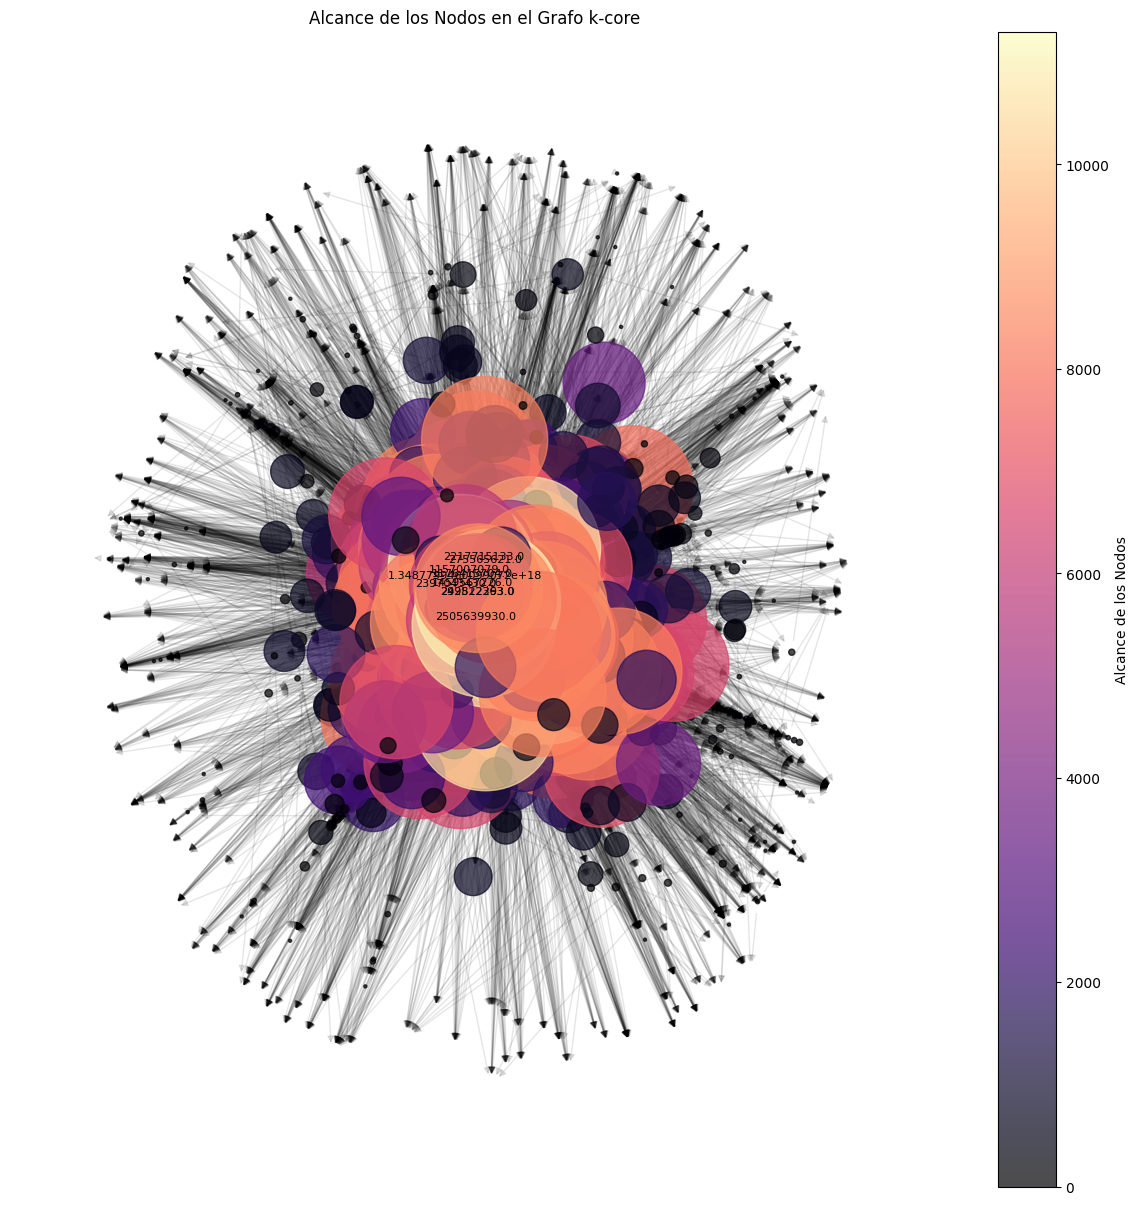

In [26]:
# Calcula el alcance de cada nodo
alcance_nodos = {nodo: len(nx.descendants(G_k_core, nodo)) for nodo in G_k_core.nodes()}
alcance_values = list(alcance_nodos.values())

# Establece las posiciones de los nodos usando el algoritmo de layout Fruchterman-Reingold
pos = nx.fruchterman_reingold_layout(G_k_core)

# Escala los valores de alcance para la visualización
scaled_alcance = [v * 5 for v in alcance_values]  # Escala ajustada para mejor visualización

# Prepara una figura
plt.figure(figsize=(15, 15))

# Dibuja los nodos con tamaños proporcionales a su alcance
nodes = nx.draw_networkx_nodes(G_k_core, pos, node_size=scaled_alcance,
                               node_color=scaled_alcance, cmap=plt.cm.magma, alpha=0.7)

# Dibuja los bordes
nx.draw_networkx_edges(G_k_core, pos, alpha=0.1)

# Etiqueta sólo los nodos con mayor alcance
top_alcance_nodes = sorted(alcance_nodos.items(), key=lambda item: item[1], reverse=True)[:10]
top_alcance_labels = {node[0]: node[0] for node in top_alcance_nodes}
nx.draw_networkx_labels(G_k_core, pos, labels=top_alcance_labels, font_size=8)

# Añade una barra de color para mostrar la escala de alcance
plt.colorbar(nodes, label='Alcance de los Nodos')

# Muestra el título y elimina los ejes
plt.title('Alcance de los Nodos en el Grafo k-core')
plt.axis('off')

# Muestra el gráfico
plt.show()

Nodos con Alto Alcance:

Los nodos representados con colores más intensos y tamaños más grandes tienen un mayor alcance. Esto sugiere que estos usuarios pueden influir en una gran cantidad de otros usuarios dentro de la red de Twitter.

Usuarios Centrales en la Discusión:

Los usuarios con un alcance más amplio pueden considerarse centrales en la discusión sobre la Ley Trans. Estos usuarios tienen la capacidad de afectar o influir en la opinión de muchos otros usuarios debido a la extensión de su alcance en la red.

Estructura de la Red y Difusión de Información:

La red muestra una estructura centralizada en torno a ciertos usuarios clave, que actúan como nodos de difusión principales. Ellos tienen el potencial de propagar información de manera eficiente a través de la red debido a la cantidad de usuarios que pueden alcanzar directamente.

Estrategias de Comunicación:

Para los individuos o entidades interesadas en difundir información o influir en la conversación sobre la Ley Trans, sería estratégico conectarse con los usuarios que tienen un mayor alcance, ya que esto podría permitir que su mensaje llegue a una parte más extensa de la red.